**Distance-Based Learning,KNN Classifier,KNN Regressor,KNN Limitations & Use Cases**

**Agenda**
- **PART 1 — Introduction to Distance-Based Learning**
- **PART 2 — Distance Metrics & Geometry Intuition**
- **PART 3 — Feature Scaling**
- **PART 4 — KNN Classifier**
- **PART 5 — Choosing K & Bias-Variance Tradeoff**
- **PART 6 — KNN Regressor**
- **PART 7 — Complexity Analysis**
- **PART 8 — Curse of Dimensionality**
- **PART 9 — KD-Tree Optimization**


#**PART 1 — Introduction to Distance-Based Learning**

**What is Distance-Based Learning?**

- Distance-Based Learning is a machine learning paradigm where predictions are made based on the similarity between data points.

**Core assumption:**

- Similar points have similar outputs.

**Intuition**

- Suppose you want to predict whether a new customer will buy a product.


**Instead of learning a formula:**

$$y = f(x)$$

**we ask:**

- "Who are the most similar customers?"


**If most similar customers purchased:**

- → Predict Purchase


**Real World Example**

- Imagine choosing a restaurant.


**You often ask:**

- "Which restaurants are similar to the ones I already like?"

This is distance-based reasoning.


**Learning by Similarity**

- Distance-based algorithms assume:

  - Nearby observations behave similarly.

**Examples:**
| Similarity       | Expected Outcome |
| ---------------- | ---------------- |
| Similar house    | Similar price    |
| Similar customer | Similar behavior |
| Similar image    | Similar class    |
| Similar document | Similar topic    |



**Lazy Learning vs Eager Learning**

- Machine learning algorithms can be divided into:


**Eager Learners**

- Examples:

  - Linear Regression
  - Logistic Regression
  - Neural Networks

They learn a model during training.

**Lazy Learners**

- Examples:

  - KNN

No explicit model training.

Store entire dataset.

Learn during prediction.

#**PART 2 — Distance Metrics & Geometry Intuition**

**Why Distance Matters**

- Distance defines:

  - What does "similar" mean?

Different distance metrics produce different neighborhoods.

This directly affects predictions.

**Euclidean Distance (L2 Distance)**

-Most common metric.

**Distance between two points:**

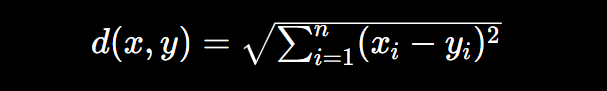

**Python Example**

In [ ]:
import numpy as np

x = np.array([1, 2])
y = np.array([4, 6])

distance = np.linalg.norm(x - y)

print(distance)

5.0


**Manhattan Distance (L1 Distance)**

- Distance measured along axes.

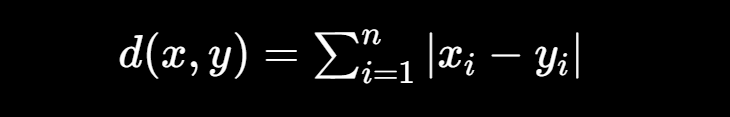

**Python Example**

In [ ]:
from scipy.spatial.distance import cityblock

x = [1, 2]
y = [4, 6]

print(cityblock(x, y))

7


#**PART 3 — Feature Scaling**

**Why Scaling is Critical**

- KNN relies entirely on distance.

Distance is highly sensitive to feature magnitude.

**Example**

- Features:
   - Age: 20-60
   - Salary: 50,000-1,000,000

Salary dominates distance.

Age becomes almost irrelevant.


**Visualization**

- Without scaling:

  - Distance ≈ Salary Difference

**With scaling:**

- Distance ≈ Balanced Contribution


**Example**

- Person A:
  - Age = 25
  - Salary = 100000

- Person B:
  - Age = 26
  - Salary = 500000

Distance mostly comes from salary.


**Standardization**

- Transforms data:

$$z=\frac{x−μ}
{σ}
$$
	​

**Python Example**

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X = np.array([
    [10, 100],
    [20, 200],
    [30, 300],
    [40, 400]
])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]


**Min-Max Scaling / Normalization**

- Maps values to:

  - [0,1]

**Formula:**
$$x′=\frac{x−x_{min}​​}{x_{max}​−x_{min}}​$$

#**PART 4 — KNN Classifier**

**KNN Classification Algorithm**


**Core Idea**

- Find K nearest neighbors.
- Let neighbors vote.
- Majority class wins.

**Algorithm Steps**
- Choose K
- Compute distances
- Sort distances
- Select K nearest neighbors
- Majority voting

**Example**
- Suppose:
  - K = 3

**Neighbors:**
- Class A
- Class A
- Class B

**Prediction:**
 - Class A


**Decision Boundary Intuition**

- KNN creates:
  - Non-linear boundaries
  - Flexible regions
  - Local decision surfaces


**Visualization**
- AAAAAAA
- AAAABBB
- AAABBBB
- BBBBBBB

Boundary adapts to data.

**Python Implementation**

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Create dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=8,
    random_state=42
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale features (important for KNN)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:10])

[1 1 0 0 1 1 0 0 0 1]


#**PART 5 — Choosing K & Bias-Variance Tradeoff**

**Why K Matters**
- K controls model complexity.

| K     | Bias | Variance |
| ----- | ---- | -------- |
| Small | Low  | High     |
| Large | High | Low      |



**Small K**

- Example:

  - K = 1

- Behavior:

  - Very flexible
  - Sensitive to noise
  - Overfitting


**Large K**

- Example:

  - K = 100

- Behavior:
   - Smooth boundaries
   - Ignores local structure
   - Underfitting

**Visualization**
- K=1

**Highly irregular boundary**
- K=50


**Smooth boundary**

**Choosing K**

- Usually determined using:

  - Validation set
  - Cross-validation
  - Grid Search


**Python Example**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

params = {
    "n_neighbors": [3,5,7,9,11]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'n_neighbors': 3}


#**PART 6 — KNN Regressor**

**What is KNN Regression?**

- Instead of majority voting:

  - Use average target value.

**Example**

- Neighbors' house prices:

  - 450K
  - 500K
  - 550K

**Prediction:**

$$(450+500+550)/3 = 500K$$

**Local Smoothing**

- KNN Regression performs:

  - Local averaging

Nearby observations smooth predictions.


**Python Example**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(
    n_neighbors=5
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

#**PART 7 — Complexity Analysis**

**Training Complexity**

- KNN does not train.


**Training:**

$$O(1)$$

- Only stores data.


**Prediction Complexity**

- For each prediction:

  - Compute distance to every point.


**Complexity:**

- $$O(Nd)$$

**Where:**

- N = number of samples
- d = dimensions

**Example**

- Dataset:
  - 1,000,000 samples
  - 100 features

Prediction becomes expensive.

**Memory Complexity**

- Stores complete dataset.

**Complexity:**

$$O(Nd)$$

#**PART 8 — Curse of Dimensionality**

**What Happens in High Dimensions?**

- As dimensions increase:
  - Distances become increasingly similar.


**Example**

- Imagine:

  - 2 dimensions

Easy to identify nearest neighbors.

- Now:

  - 1000 dimensions

All points become far apart.

**Key Insight**
- Nearest Neighbor ≈ Farthest Neighbor

Distance loses meaning.

**Why This Happens**

- Volume grows exponentially.

Data becomes sparse.

Neighborhood structure collapses.


**Mitigation Strategies**

- **Feature Selection**

  - Remove irrelevant features.

- **PCA**

  - Reduce dimensions.

Approximate Nearest Neighbor

Avoid exact distance calculations.

#**PART 9 — KD-Tree Optimization**

**What is a KD-Tree?**

- KD-Tree:

  - K-Dimensional Tree

A space-partitioning data structure for efficient nearest-neighbor search.

**Construction Intuition**
- Choose dimension
- Split at median
- Create left subtree
- Create right subtree
- Alternate dimensions


**Search Procedure**
- Traverse tree
- Reach leaf node
- Compute distance
- Backtrack
- Prune branches


**Why Faster?**
- Avoid computing distance to every point.
- Large regions are discarded.

**Complexity**
| Operation   | Complexity |
| ----------- | ---------- |
| Build Tree  | O(N log N) |
| Query Avg   | O(log N)   |
| Query Worst | O(N)       |


**KD-Tree vs Brute Force**
| Aspect          | Brute Force | KD-Tree  |
| --------------- | ----------- | -------- |
| Search          | Slow        | Faster   |
| Preprocessing   | None        | Required |
| High Dimensions | Works       | Breaks   |
| Scalability     | Poor        | Moderate |


**Why KD-Tree Fails**
- As dimensions increase:

  - Tree pruning fails
  - Distance differences vanish
  - Search degenerates

**Eventually:**

- KD-Tree ≈ Brute Force